# IntellBank Data Exploration & Cleaning

### Pipeline Flow Confirmation:
1. **OCR & Extraction:** PDF is uploaded and converted to raw text.
2. **Data Cleaning (This Step):** We analyze the raw text, remove missing values, filter outliers (e.g. extremely short/long strings), and standardize the text.
3. **Data Transformation (Separated):**
   - *For Generation (FLAN-T5):* Transform clean data into `input_text` and `target_text` pairs.
   - *For Topic Heatmap:* Transform clean data into TF-IDF vectors for clustering.

In [1]:
!pip install matplotlib seaborn jupyter numpy pandas scikit-learn

'c:\Users\samch\Downloads\School\Y2S3\FYP\IntellBank\ai-service\venv\Scripts\pip.exe' was blocked by your organization's Device Guard policy.
Contact your support person for more info.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

sns.set_theme(style="whitegrid")
DATASET_PATH = os.path.join("app", "data", "training_dataset.csv")

# Load the data
df = pd.read_csv(DATASET_PATH)
df['target_len'] = df['target_text'].astype(str).str.len()
df['input_len'] = df['input_text'].astype(str).str.len()


In [4]:
# list out the table of the columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   subject      86 non-null     str    
 1   topic        86 non-null     str    
 2   difficulty   86 non-null     str    
 3   marks        61 non-null     float64
 4   year         86 non-null     int64  
 5   input_text   86 non-null     str    
 6   target_text  86 non-null     str    
 7   source_file  86 non-null     str    
 8   pyp_id       86 non-null     str    
 9   target_len   86 non-null     int64  
 10  input_len    86 non-null     int64  
dtypes: float64(1), int64(3), str(7)
memory usage: 49.5 KB


In [5]:
df.head()

,subject,topic,difficulty,marks,year,input_text,target_text,source_file,pyp_id,target_len,input_len
0,Software Project Management,Stakeholders,Medium,6.0,2026,Generate a Medium 6-mark Software Project Mana...,Identify and describe TWO (2) stakeholders of ...,Software Engineering Test 1,77fe2d39-f87a-4e13-a6ec-efdfe21c40b2,62,81
1,Software Project Management,Software Process Model,Medium,6.0,2026,Generate a Medium 6-mark Software Project Mana...,Identify and explain TWO (2) types of prototyp...,Software Engineering Test 1,77fe2d39-f87a-4e13-a6ec-efdfe21c40b2,145,91
2,Software Project Management,Software Process Model,Medium,NaN,2026,Generate a Medium Software Project Management...,A network diagram can be used to illustrate th...,Software Engineering Test 1,77fe2d39-f87a-4e13-a6ec-efdfe21c40b2,491,85
3,Software Project Management,Network Diagram,Hard,8.0,2026,Generate a Hard 8-mark Software Project Manage...,"Create a network diagram based on the task ID,...",Software Engineering Test 1,77fe2d39-f87a-4e13-a6ec-efdfe21c40b2,94,82
4,Software Project Management,Network Diagram,Medium,5.0,2026,Generate a Medium 5-mark Software Project Mana...,Based on the answer given in Question 1 c) (i)...,Software Engineering Test 1,77fe2d39-f87a-4e13-a6ec-efdfe21c40b2,206,84


In [7]:
df.isnull().sum()

subject         0
topic           0
difficulty      0
marks          25
year            0
input_text      0
target_text     0
source_file     0
pyp_id          0
target_len      0
input_len       0
dtype: int64

## Step 1: Show Raw Values and Missing Data
Before we generate any graphs or do any cleaning, let's look at the raw state of our dataset.

In [ ]:
print("--- DATASET INFO ---")
df.info()

print("\n--- MISSING VALUES ---")
print(df.isnull().sum())

print("\n--- STATISTICAL SUMMARY (Character Lengths) ---")
display(df[['input_len', 'target_len']].describe())

print("\n--- FIRST 5 ROWS ---")
display(df.head())

In [10]:
categorical_data = df.select_dtypes(include=['object'])
continuous_data = df.select_dtypes(include=['int64', 'float64'])

print("Categorical Data")
i = 1
for cate_columns in categorical_data.columns:
    print(f"{i}. {cate_columns}")
    i+=1

print("\nContinuous Data")
i = 1
for cont_columns in continuous_data.columns:
    print(f"{i}. {cont_columns}")
    i+=1

Categorical Data
1. subject
2. topic
3. difficulty
4. input_text
5. target_text
6. source_file
7. pyp_id

Continuous Data
1. marks
2. year
3. target_len
4. input_len


C:\Users\samch\AppData\Local\Temp\ipykernel_3996\3363940434.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_data = df.select_dtypes(include=['object'])


## Step 2: Data Cleaning Suggestions & Choices

Based on the raw data above, here are the standard choices you have for cleaning this OCR data before passing it to transformation:

1. **Drop Missing Values (NaNs):** Remove any row where `target_text` or `input_text` is entirely blank or null.
2. **Outlier Removal (Length):** 
   - Drop rows where `target_len < 10` (likely an OCR error that just captured a single word).
   - Drop rows where `target_len > 1500` (likely an OCR error that merged 5 questions into 1).
3. **Text Standardization:** Convert all text to lowercase, remove weird characters (e.g., `\r\n`), and strip extra whitespaces. (Already mostly done in `ocr_to_dataset.py`, but good to double-check).
4. **Drop Unknown Topics:** If a topic was classified as 'Unknown', do you want to keep it or drop it?

### Let's visualize the data to see if we need outlier removal:

In [11]:
df_clean = df.dropna(subset=['input_text', 'target_text', 'topic'])

df_clean = df_clean[df_clean['topic'] != 'Unknown']

print(f"Original row count: {len(df)}")
print(f"Cleaned row count: {len(df_clean)}")
print(f"Total rows removed: {len(df) - len(df_clean)}")

df = df_clean


Original row count: 86
Cleaned row count: 79
Total rows removed: 7


C:\Users\samch\AppData\Local\Temp\ipykernel_3996\3437715888.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='difficulty', ax=axes[1], palette='viridis')


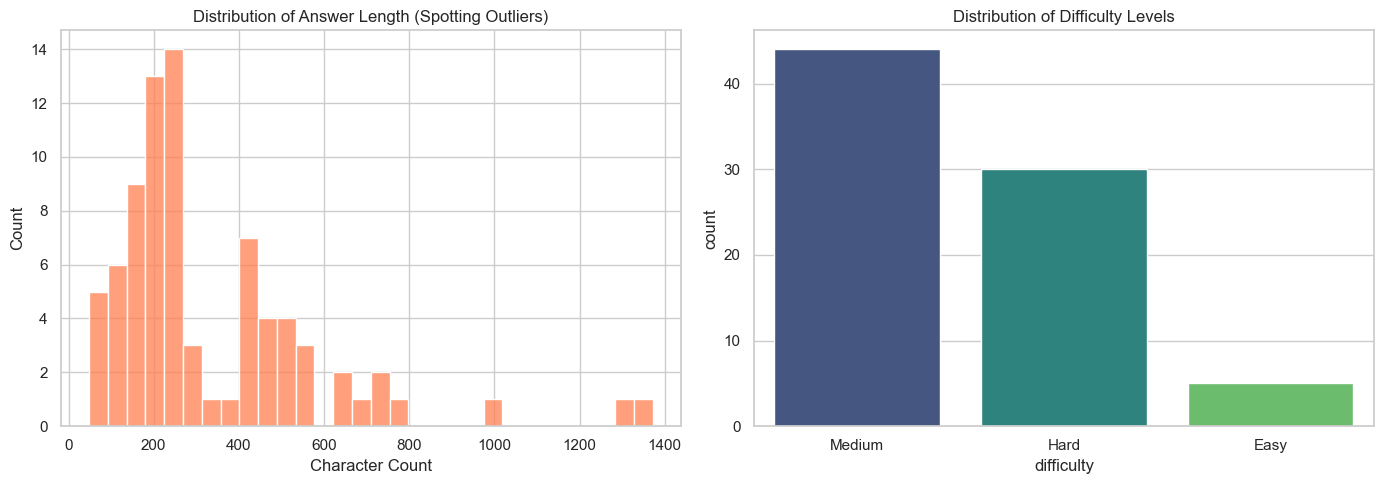

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Length Distribution
sns.histplot(data=df, x='target_len', bins=30, ax=axes[0], color='coral')
axes[0].set_title('Distribution of Answer Length (Spotting Outliers)')
axes[0].set_xlabel('Character Count')

# Difficulty Distribution
sns.countplot(data=df, x='difficulty', ax=axes[1], palette='viridis')
axes[1].set_title('Distribution of Difficulty Levels')

plt.tight_layout()
plt.show()

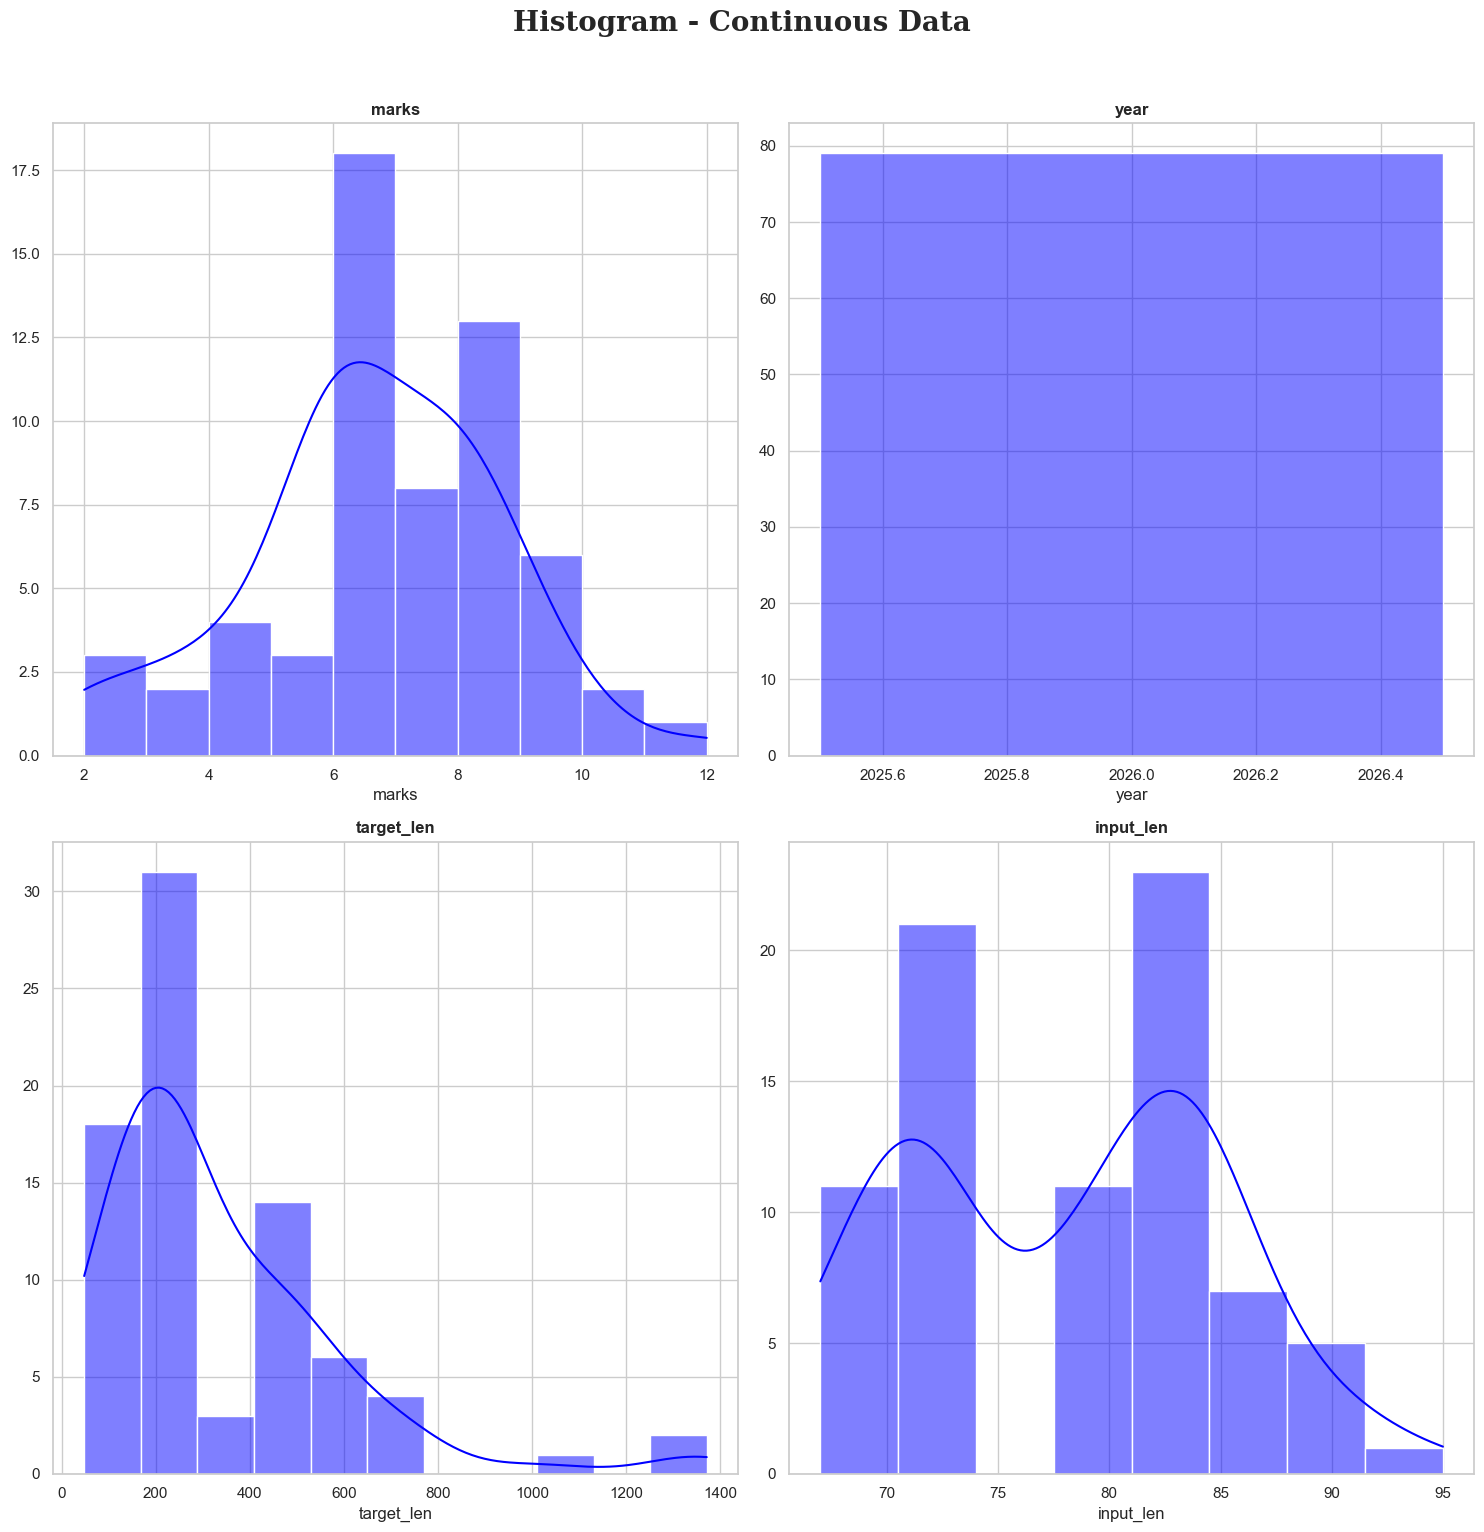

In [15]:
fig, axs = plt.subplots(2, 2, figsize=(15, 15))
axs = axs.flatten()

for i, column in enumerate(continuous_data.columns):
    sns.histplot(data=df, x=column, ax=axs[i], kde=True, color='blue')
    axs[i].set_title(column, fontweight='bold')
    axs[i].set_ylabel('')

    fig.suptitle(
        "Histogram - Continuous Data",
        fontsize = 20,
        fontweight = 'bold',
        fontfamily = 'serif',
        y=1.02
    )

plt.tight_layout()
plt.show()

In [16]:
# Drop the 'year' column permanently
df = df.drop(columns=['year'])


## Step 3: Data Transformation (Example: Clustering)
Once the data is cleaned above, we transform it. Here is the separated transformation path for your **Topic Heatmap**.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# 1. Clean the subset (drop missing)
clean_texts = df['target_text'].dropna().astype(str)

# 2. Transform into vectors
vectorizer = TfidfVectorizer(stop_words='english', max_features=500)
X = vectorizer.fit_transform(clean_texts)

# 3. Run clustering algorithm
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X)

order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()

for i in range(5):
    top_terms = [terms[ind] for ind in order_centroids[i, :7]]
    print(f"Cluster {i}: {', '.join(top_terms)}")